Módulos importados.
Carregando dados...
Pool U0: (175255, 2), Avaliação P: (75110, 2), Classes: 622
Classes únicas em U0: 622
Configurando componentes...
Embedder Semântico para K-Means do DRI: ProductVectorizerEmbedder.
Model Factory: Criando tipo 'PVBin' com params: {'method': 'binary', 'ngram_range': (1, 2), 'norm': None}
Classificador Rápido para avaliação: PVBin.
Função para N_clusters (Logística) definida.
Treinando o Embedder Semântico (PVEmbedder para K-Means do DRI) em todo o U0...
Embedder Semântico (K-Means) treinado globalmente em 3.63s.


Testando Tamanhos de L0:   0%|          | 0/12 [00:00<?, ?it/s]


--- Processando L0_size = 10 ---
  Rodando DRI-Cluster para L0=10 com n_clusters_semantic=10...
DRIClusterColdStart inicializado. Alvo L0: 10, Clusters Semânticos Solicitados: 10, Log: D:\Nuvem\ghdaru\OneDrive\030_DOUTORADO\120_TESE\130_TESEGIT\activetextclassification\data_splits_cache\dri_coldstart_selection_details_log.csv
DRI: Iniciando. Alvo: 10, U0: 175255 textos.
  DRI: 1. Clustering Semântico (K-Means)...
    K-Means concluído em 14.95s. 10 clusters semânticos.
  DRI: 2. Preparando ProductVectorizer interno...
    PV Interno pronto em 6.15s. Matriz A: (31594, 10), Matriz q_x: (175255, 31594)
  DRI: Alocação por cluster semântico: [1 1 1 1 1 1 1 1 1 1]
  DRI: 3. Seleção Intra-Cluster Principal...
    Cluster Sem. 0 (PV idx 0): Sel. 1 de 1658.
    Cluster Sem. 1 (PV idx 1): Sel. 1 de 797.
    Cluster Sem. 2 (PV idx 2): Sel. 1 de 8443.
    Cluster Sem. 3 (PV idx 3): Sel. 1 de 1910.
    Cluster Sem. 4 (PV idx 4): Sel. 1 de 6262.
    Cluster Sem. 5 (PV idx 5): Sel. 1 de 5414.
    C

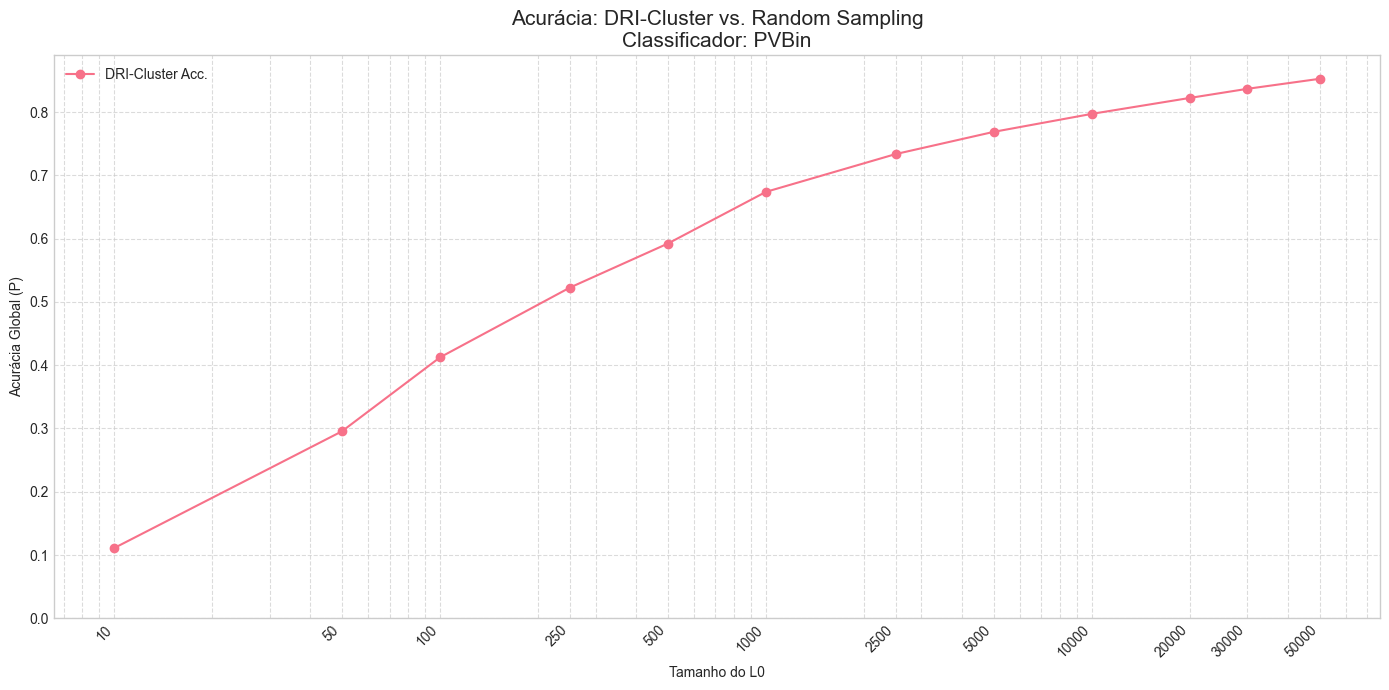

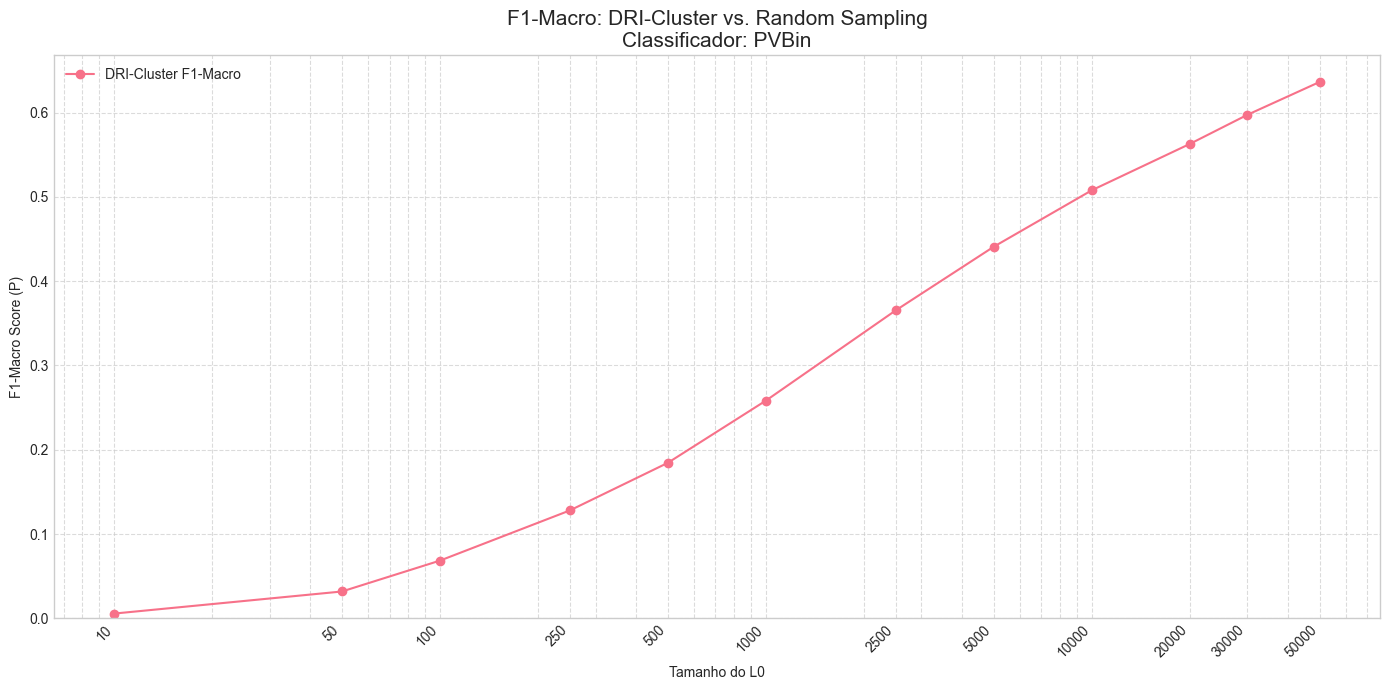

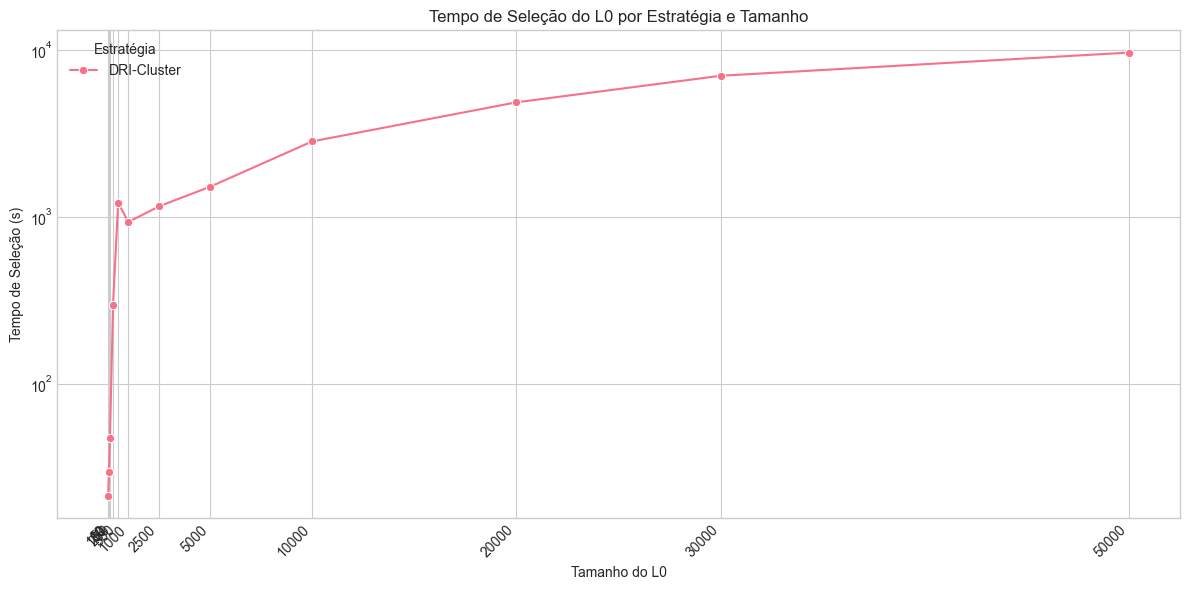

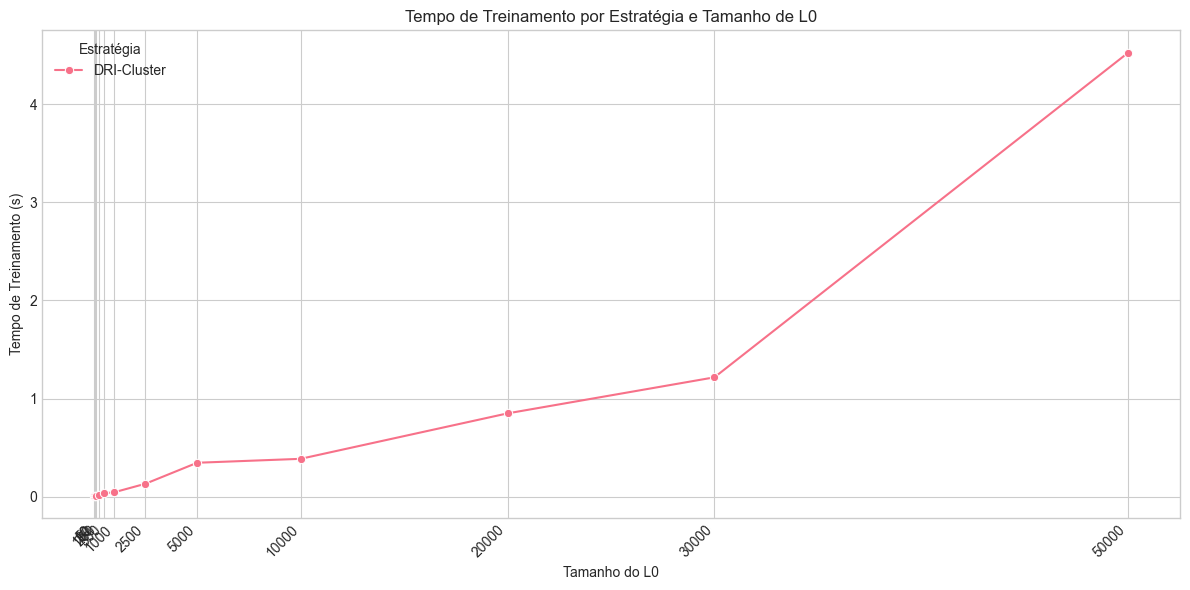


Tempo médio para treinar o Embedder Semântico (K-Means) globalmente (para DRI): 3.63s


In [1]:
# %% [markdown]
# # Avaliação de Estratégias de Cold Start (DRI-Cluster vs. Aleatório)
#
# Este notebook tem como objetivo:
# 1. Implementar e avaliar a estratégia de cold start DRI-Cluster para diferentes tamanhos de L0.
#    - DRI-Cluster usa um embedder semântico para K-Means e um ProductVectorizer interno.
# 2. Comparar o DRI-Cluster com uma amostragem aleatória simples (1 repetição).
#
# O classificador utilizado para avaliação rápida dos L0s é o ProductVectorizer Binário (PVBin).
# O conjunto de avaliação (P) é o `df_test_T.csv`.
# O pool não rotulado (U0) é o `df_train_opt.csv`.

# %% [markdown]
# ## 1. Configurações e Imports

# %%
import os
import sys
import time
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import matplotlib.ticker as mticker
import csv # Para o log do DRI

from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import shuffle

try:
    from activetextclassification.cold_start.dri_cluster import DRIClusterColdStart
    from activetextclassification.models import get_model
    from activetextclassification.embeddings import ProductVectorizerEmbedder 
    from sentence_transformers import SentenceTransformer 
    print("Módulos importados.")
except Exception as e:
    print(f"Erro importação: {e}")

plt.style.use('seaborn-v0_8-whitegrid') 
sns.set_palette("husl") 

BASE_DATA_PATH = r"D:\Nuvem\ghdaru\OneDrive\030_DOUTORADO\120_TESE\130_TESEGIT\activetextclassification\data_splits_cache"
DF_TRAIN_OPT_PATH = os.path.join(BASE_DATA_PATH, "df_train_opt.csv") 
DF_TEST_T_PATH = os.path.join(BASE_DATA_PATH, "df_test_T.csv")      
ALL_LABELS_PATH = os.path.join(BASE_DATA_PATH, "all_possible_labels_original.json")
# Log detalhado para as seleções do DRI-Cluster
DETAILED_DRI_SELECTION_LOG_PATH = os.path.join(BASE_DATA_PATH, "dri_coldstart_selection_details_log.csv") 


TEXT_COLUMN = "nm_item" 
LABEL_COLUMN = "nm_product"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
if hasattr(pd.core.common, 'random_state'): pd.core.common.random_state(RANDOM_SEED)

# %% [markdown]
# ## 2. Carregamento e Preparação dos Dados

# %%
print("Carregando dados...")
try:
    df_U0_full_original = pd.read_csv(DF_TRAIN_OPT_PATH)
    df_P_eval = pd.read_csv(DF_TEST_T_PATH)
    with open(ALL_LABELS_PATH, 'r', encoding='utf-8') as f: 
        all_possible_labels = sorted(list(set(json.load(f)))) 
    print(f"Pool U0: {df_U0_full_original.shape}, Avaliação P: {df_P_eval.shape}, Classes: {len(all_possible_labels)}")
except Exception as e: print(f"ERRO ao carregar dados: {e}")

for df_temp in [df_U0_full_original, df_P_eval]:
    if TEXT_COLUMN not in df_temp.columns: 
        if 'ds_unificado_sem_acento' in df_temp.columns:
            df_temp.rename(columns={'ds_unificado_sem_acento': TEXT_COLUMN}, inplace=True)
        else: raise ValueError(f"Coluna '{TEXT_COLUMN}' não encontrada.")
    if LABEL_COLUMN not in df_temp.columns: raise ValueError(f"Coluna '{LABEL_COLUMN}' não encontrada.")
    df_temp[TEXT_COLUMN] = df_temp[TEXT_COLUMN].astype(str).fillna(''); df_temp[LABEL_COLUMN] = df_temp[LABEL_COLUMN].astype(str)
n_unique_classes_U0_original = df_U0_full_original[LABEL_COLUMN].nunique()
print(f"Classes únicas em U0: {n_unique_classes_U0_original}")

# %% [markdown]
# ## 3. Definição de Componentes e Parâmetros Experimentais

# %%
print("Configurando componentes...")

# --- Embedder Semântico para K-Means inicial do DRI-Cluster ---
# Opção 1: ProductVectorizerEmbedder (treinado em U0 com rótulos)
PV_EMB_SEMANTIC_INTERNAL_PARAMS = {'method': 'tfidf', 'ngram_range': (1, 1), 'norm': 'l2'}
PV_EMB_SEMANTIC_CONFIG = {'vectorizer_params': PV_EMB_SEMANTIC_INTERNAL_PARAMS, 'cache_dir': None }
try:
    semantic_embedder_for_kmeans_dri = ProductVectorizerEmbedder(**PV_EMB_SEMANTIC_CONFIG)
    print(f"Embedder Semântico para K-Means do DRI: ProductVectorizerEmbedder.")
except Exception as e:
    print(f"ERRO ao instanciar PV Embedder para K-Means: {e}."); semantic_embedder_for_kmeans_dri = None

# Opção 2: SentenceTransformer (comentada, mas disponível)
# try:
#     # semantic_embedder_for_kmeans_dri = SentenceTransformer('distiluse-base-multilingual-cased-v1')
#     # print(f"Embedder Semântico para K-Means do DRI: SentenceTransformer carregado.")
# except Exception as e:
#     print(f"ERRO ao carregar SentenceTransformer: {e}."); semantic_embedder_for_kmeans_dri = None


CLASSIFIER_CONFIG_RAPIDO = {"type": "PVBin", "params": {"method": "binary", "ngram_range": (1, 2), "norm": None}}
try:
    _test_model = get_model(CLASSIFIER_CONFIG_RAPIDO) 
    print(f"Classificador Rápido para avaliação: {CLASSIFIER_CONFIG_RAPIDO['type']}.")
except Exception as e: print(f"ERRO classificador rápido: {e}"); _test_model = None

L0_SIZES_TO_TEST = [10, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000, 30000, 50000] 
N_REPETITIONS_RANDOM = 1 
DRI_VERBOSE = True 
K_LOGISTICO_AJUSTADO = 0.000646 
L0_MID_LOGISTICO_AJUSTADO = 2482.08
N_CLASSES_TOTAL_U0_REF = n_unique_classes_U0_original 

def calcular_nc_via_logistica(l0_size_atual, n_classes_total_ref, k_param, l0_mid_param):
    nc_calculado = n_classes_total_ref / (1 + np.exp(-k_param * (l0_size_atual - l0_mid_param)))
    nc_final = np.clip(nc_calculado, 1, min(l0_size_atual, n_classes_total_ref))
    return int(round(nc_final))
print(f"Função para N_clusters (Logística) definida.")

# %% [markdown]
# ## 4. Função Auxiliar para Treinamento e Avaliação
# (Sem mudanças)

# %%
def train_evaluate_l0(l0_df, p_eval_df, classifier_config_dict, 
                      txt_col, lbl_col, all_labels_list,
                      experiment_id_str=""):
    if l0_df is None or l0_df.empty:
        return {"accuracy": np.nan, "f1_macro": np.nan, "train_time_sec": 0, "eval_time_sec": 0}
    l0_texts = l0_df[txt_col].tolist(); l0_labels = l0_df[lbl_col].tolist()
    p_texts = p_eval_df[txt_col].tolist(); p_labels_true = p_eval_df[lbl_col].tolist()
    try: model = get_model(classifier_config_dict)
    except Exception as e: return {"accuracy": np.nan, "f1_macro": np.nan, "train_time_sec": 0, "eval_time_sec": 0}
    ts = time.time(); train_time_sec = 0
    try: model.fit(l0_texts, l0_labels)
    except Exception as e: return {"accuracy": np.nan, "f1_macro": np.nan, "train_time_sec": time.time() - ts, "eval_time_sec": 0}
    train_time_sec = time.time() - ts
    ts = time.time(); eval_time_sec = 0
    try: p_labels_pred = model.predict(p_texts)
    except Exception as e: return {"accuracy": np.nan, "f1_macro": np.nan, "train_time_sec": train_time_sec, "eval_time_sec": time.time() - ts}
    eval_time_sec = time.time() - ts
    accuracy = accuracy_score(p_labels_true, p_labels_pred)
    f1_macro = f1_score(p_labels_true, p_labels_pred, labels=all_labels_list, average='macro', zero_division=0)
    return {"accuracy": accuracy, "f1_macro": f1_macro, "train_time_sec": train_time_sec, "eval_time_sec": eval_time_sec}

# %% [markdown]
# ## 5. Loop Experimental Principal

# %%
results_list = []
overall_start_time = time.time()

u0_full_texts = df_U0_full_original[TEXT_COLUMN].tolist()
u0_full_labels = df_U0_full_original[LABEL_COLUMN].tolist()
u0_full_indices = df_U0_full_original.index.to_numpy()

fit_semantic_embedder_time_global = 0
if semantic_embedder_for_kmeans_dri:
    if isinstance(semantic_embedder_for_kmeans_dri, ProductVectorizerEmbedder):
        print(f"Treinando o Embedder Semântico (PVEmbedder para K-Means do DRI) em todo o U0...")
        fit_sem_emb_start_time = time.time()
        try:
            semantic_embedder_for_kmeans_dri.fit(u0_full_texts, u0_full_labels) 
            fit_semantic_embedder_time_global = time.time() - fit_sem_emb_start_time
            print(f"Embedder Semântico (K-Means) treinado globalmente em {fit_semantic_embedder_time_global:.2f}s.")
        except Exception as e:
            print(f"ERRO CRÍTICO ao treinar Embedder Semântico (K-Means) globalmente: {e}.")
    else:
        print(f"Embedder Semântico '{type(semantic_embedder_for_kmeans_dri).__name__}' não requer fit com labels de U0.")

for l0_size in tqdm(L0_SIZES_TO_TEST, desc="Testando Tamanhos de L0"):
    print(f"\n--- Processando L0_size = {l0_size} ---")
    
    n_clusters_for_dri = calcular_nc_via_logistica(l0_size, N_CLASSES_TOTAL_U0_REF, K_LOGISTICO_AJUSTADO, L0_MID_LOGISTICO_AJUSTADO)
    n_clusters_for_dri = max(1, min(n_clusters_for_dri, l0_size, len(df_U0_full_original)))
    
    run_id_current_dri = f"DRI_L0size{l0_size}_Nc{n_clusters_for_dri}_Seed{RANDOM_SEED + l0_size}"

    if semantic_embedder_for_kmeans_dri: 
        print(f"  Rodando DRI-Cluster para L0={l0_size} com n_clusters_semantic={n_clusters_for_dri}...")
        dri_selector = DRIClusterColdStart(
            i_target=l0_size,
            semantic_embedder=semantic_embedder_for_kmeans_dri, 
            n_clusters_semantic=n_clusters_for_dri,
            random_seed=RANDOM_SEED + l0_size, 
            min_samples_per_cluster=1,
            verbose=DRI_VERBOSE,
            detailed_log_path=DETAILED_DRI_SELECTION_LOG_PATH, # Passar o caminho do log
            run_id=run_id_current_dri # Passar o ID da execução
        )
        dri_sel_start_time = time.time()
        try:
            l0_texts_dri, sel_indices_dri_orig = dri_selector.select_initial_samples(
                U0_texts=u0_full_texts,
                U0_labels=u0_full_labels, # Passando U0_labels para o log
                U0_indices=u0_full_indices 
            )
            dri_sel_time = time.time() - dri_sel_start_time
            
            temp_l0_labels_dri = df_U0_full_original.loc[sel_indices_dri_orig, LABEL_COLUMN].tolist()
            l0_df_dri_eval = pd.DataFrame({TEXT_COLUMN: l0_texts_dri, LABEL_COLUMN: temp_l0_labels_dri})

            if l0_df_dri_eval.empty and l0_size > 0: print(f"AVISO (DRI): L0 VAZIO para L0_size={l0_size}.")
            metrics_dri = train_evaluate_l0(l0_df_dri_eval, df_P_eval, CLASSIFIER_CONFIG_RAPIDO, TEXT_COLUMN, LABEL_COLUMN, all_possible_labels, f"DRI L0={l0_size}")
            results_list.append({"l0_size": l0_size, "strategy": "DRI-Cluster", **metrics_dri, "selection_time_sec": dri_sel_time, "fit_embedder_time_sec": fit_semantic_embedder_time_global})
            print(f"    DRI-Cluster (L0={l0_size}): Acc={metrics_dri['accuracy']:.4f}, F1M={metrics_dri['f1_macro']:.4f}, SelTime={dri_sel_time:.2f}s")
        except Exception as e:
            print(f"    ERRO DRI-Cluster L0={l0_size}: {e}"); import traceback; traceback.print_exc()
            results_list.append({"l0_size": l0_size, "strategy": "DRI-Cluster", "accuracy": np.nan, "f1_macro": np.nan, "train_time_sec": np.nan, "eval_time_sec": np.nan, "selection_time_sec": time.time() - dri_sel_start_time, "fit_embedder_time_sec": fit_semantic_embedder_time_global})
    else:
        print(f"  AVISO: Embedder semântico não disponível. Pulando DRI-Cluster L0={l0_size}.")

    

    # print(f"  Rodando Amostragem Aleatória para L0={l0_size} ({N_REPETITIONS_RANDOM} reps)...")
    # rand_acc_lst, rand_f1_lst, rand_sel_t, rand_train_t, rand_eval_t = [],[],0,0,0
    # for rep in range(N_REPETITIONS_RANDOM):
    #     rs_st = time.time()
    #     l0_df_rand = df_U0_full_original.sample(n=min(l0_size, len(df_U0_full_original)), random_state=RANDOM_SEED+rep+l0_size)
    #     rand_sel_t+=(time.time()-rs_st)
    #     m_rand = train_evaluate_l0(l0_df_rand, df_P_eval, CLASSIFIER_CONFIG_RAPIDO, TEXT_COLUMN, LABEL_COLUMN, all_possible_labels, f"Rand L0={l0_size}R{rep+1}")
    #     rand_acc_lst.append(m_rand['accuracy']); rand_f1_lst.append(m_rand['f1_macro']); rand_train_t+=m_rand['train_time_sec']; rand_eval_t+=m_rand['eval_time_sec']
    # results_list.append({"l0_size": l0_size, "strategy": "Random", "accuracy": np.mean(rand_acc_lst) if rand_acc_lst else np.nan, "accuracy_std": np.std(rand_acc_lst) if rand_acc_lst and N_REPETITIONS_RANDOM > 1 else 0.0, "f1_macro": np.mean(rand_f1_lst) if rand_f1_lst else np.nan, "f1_macro_std": np.std(rand_f1_lst) if rand_f1_lst and N_REPETITIONS_RANDOM > 1 else 0.0, "train_time_sec": rand_train_t/N_REPETITIONS_RANDOM if N_REPETITIONS_RANDOM>0 else np.nan, "eval_time_sec": rand_eval_t/N_REPETITIONS_RANDOM if N_REPETITIONS_RANDOM > 0 else np.nan, "selection_time_sec": rand_sel_t/N_REPETITIONS_RANDOM if N_REPETITIONS_RANDOM > 0 else np.nan, "fit_embedder_time_sec": 0 })
    # print(f"    Random (L0={l0_size}, Avg): Acc={np.mean(rand_acc_lst):.4f}, F1M={np.mean(rand_f1_lst):.4f}")
        
    results_df = pd.DataFrame(results_list)
    print(f"\n--- Processamento Concluído (Tempo total: {time.time() - overall_start_time:.2f}s) ---")
    pd.set_option('display.float_format', lambda x: '%.4f' % x)
    print("\nSumário dos Resultados:"); print(results_df)
    output_fn = "dri_vs_random_final_log_results.csv" 
    results_df.to_csv(os.path.join(BASE_DATA_PATH, output_fn), index=False)
    print(f"\nResultados salvos em: {os.path.join(BASE_DATA_PATH, output_fn)}")

# %% [markdown]
# ## 6. Análise e Visualização dos Resultados

# %%
if results_df.empty: print("DataFrame de resultados vazio.")
else:
    df_plot_dri = results_df[results_df['strategy'] == 'DRI-Cluster'].sort_values(by='l0_size').dropna(subset=['accuracy', 'f1_macro'])
    df_plot_random = results_df[results_df['strategy'] == 'Random'].sort_values(by='l0_size').dropna(subset=['accuracy', 'f1_macro'])
    
    plt.figure(figsize=(14, 7))
    if not df_plot_dri.empty: plt.plot(df_plot_dri['l0_size'], df_plot_dri['accuracy'], label='DRI-Cluster Acc.', marker='o', linestyle='-')
    if not df_plot_random.empty: plt.plot(df_plot_random['l0_size'], df_plot_random['accuracy'], label='Random Acc.', marker='x', linestyle='--')
    plt.title(f'Acurácia: DRI-Cluster vs. Random Sampling\nClassificador: {CLASSIFIER_CONFIG_RAPIDO["type"]}', fontsize=15)
    plt.xlabel('Tamanho do L0'); plt.ylabel('Acurácia Global (P)'); plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7); plt.ylim(bottom=0); plt.xscale('log')
    unique_ticks = sorted(list(set(L0_SIZES_TO_TEST)))
    plt.xticks(unique_ticks, labels=[str(s) for s in unique_ticks], rotation=45, ha="right"); plt.tight_layout(); plt.show()

    plt.figure(figsize=(14, 7))
    if not df_plot_dri.empty: plt.plot(df_plot_dri['l0_size'], df_plot_dri['f1_macro'], label='DRI-Cluster F1-Macro', marker='o', linestyle='-')
    if not df_plot_random.empty: plt.plot(df_plot_random['l0_size'], df_plot_random['f1_macro'], label='Random F1-Macro', marker='x', linestyle='--')
    plt.title(f'F1-Macro: DRI-Cluster vs. Random Sampling\nClassificador: {CLASSIFIER_CONFIG_RAPIDO["type"]}', fontsize=15)
    plt.xlabel('Tamanho do L0'); plt.ylabel('F1-Macro Score (P)'); plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7); plt.ylim(bottom=0); plt.xscale('log') 
    plt.xticks(unique_ticks, labels=[str(s) for s in unique_ticks], rotation=45, ha="right"); plt.tight_layout(); plt.show()

# %% [markdown]
# ## 7. Análise dos Tempos de Execução

# %%
if not results_df.empty:
    time_cols = ['selection_time_sec', 'train_time_sec', 'eval_time_sec', 'fit_embedder_time_sec']
    df_times = results_df.copy() 
    for tc in time_cols:
        if tc in df_times.columns: df_times[tc] = pd.to_numeric(df_times[tc], errors='coerce')
    df_times_sel = df_times.dropna(subset=['selection_time_sec'])
    df_times_train = df_times.dropna(subset=['train_time_sec'])

    if not df_times_sel.empty:
        plt.figure(figsize=(12, 6))
        sns.lineplot(data=df_times_sel, x='l0_size', y='selection_time_sec', hue='strategy', marker='o', errorbar=None) 
        plt.title('Tempo de Seleção do L0 por Estratégia e Tamanho'); plt.ylabel('Tempo de Seleção (s)'); plt.xlabel('Tamanho do L0'); plt.yscale('log') 
        plt.xticks(L0_SIZES_TO_TEST, labels=[str(s) for s in L0_SIZES_TO_TEST], rotation=45, ha='right'); plt.legend(title='Estratégia'); plt.tight_layout(); plt.show()

    if not df_times_train.empty:
        plt.figure(figsize=(12, 6))
        sns.lineplot(data=df_times_train, x='l0_size', y='train_time_sec', hue='strategy', marker='o', errorbar=None)
        plt.title('Tempo de Treinamento por Estratégia e Tamanho de L0'); plt.ylabel('Tempo de Treinamento (s)'); plt.xlabel('Tamanho do L0')
        plt.xticks(L0_SIZES_TO_TEST, labels=[str(s) for s in L0_SIZES_TO_TEST], rotation=45, ha='right'); plt.legend(title='Estratégia'); plt.tight_layout(); plt.show()

    df_dri_fit_emb_times = df_times[df_times['strategy'] == 'DRI-Cluster'].dropna(subset=['fit_embedder_time_sec'])
    if not df_dri_fit_emb_times.empty and 'fit_embedder_time_sec' in df_dri_fit_emb_times.columns :
        avg_fit_emb_time = df_dri_fit_emb_times['fit_embedder_time_sec'].mean()
        if pd.notna(avg_fit_emb_time) and avg_fit_emb_time > 0 : # Checar se é um número válido > 0
             print(f"\nTempo médio para treinar o Embedder Semântico (K-Means) globalmente (para DRI): {avg_fit_emb_time:.2f}s")
        elif pd.notna(avg_fit_emb_time) and avg_fit_emb_time == 0:
             print("\nEmbedder semântico (K-Means) para DRI não precisou de treinamento (e.g., SentenceTransformer) ou o tempo foi zero.")
    else: print("Não há dados de tempo de fit do embedder semântico para DRI-Cluster.")
else: print("Não há dados de tempo para plotar.")